In [2]:
import torch
import torch.nn as nn

from pathlib import Path
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
print(f"PyTorch: ", torch.__version__)
print(f"Device: ", device)

PyTorch:  2.14.0+cu130
Device:  cuda


In [5]:
if device.type == "cuda":
    print(f"GPU: ", torch.cuda.get_device_name(0))

GPU:  NVIDIA GeForce RTX 3050 A Laptop GPU


In [6]:
image_path = Path("../disease_dataset/processed/banana/Bacterial_Soft_Rot/BACTERIAL_SOFT_ROT (1).jpg")

In [7]:
image = Image.open(image_path).convert("RGB")

In [8]:
print("Image Size: ", image.size)

Image Size:  (256, 256)


In [9]:
print("Image Mode:", image.mode)

Image Mode: RGB


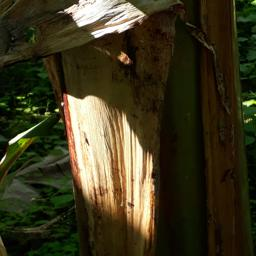

In [10]:
image

In [11]:
image_tensor = torch.from_numpy(
    np.array(image)
).permute(2, 0, 1).float()

In [12]:
print("Image shape: ", image_tensor.shape)
print("Data Type: ", image_tensor.dtype)
print("Min: ", image_tensor.min())
print("Max: ", image_tensor.max())

Image shape:  torch.Size([3, 256, 256])
Data Type:  torch.float32
Min:  tensor(0.)
Max:  tensor(255.)


In [13]:
image_tensor[0]

tensor([[ 66.,  58.,  45.,  ...,  27., 109., 178.],
        [ 67.,  42.,  32.,  ..., 146., 191., 207.],
        [ 50.,  44.,  52.,  ..., 164., 163., 176.],
        ...,
        [ 68.,  70.,  80.,  ...,  19.,   9.,   6.],
        [ 74.,  64.,  75.,  ...,  21.,  11.,   7.],
        [ 76.,  60.,  71.,  ...,  22.,  12.,   8.]])

In [14]:
x = image_tensor.unsqueeze(0)

In [15]:
print("Shape: ", x.shape)
print("Data Type: ", x.dtype)

Shape:  torch.Size([1, 3, 256, 256])
Data Type:  torch.float32


In [16]:
conv = nn.Conv2d(
    in_channels=3, 
    out_channels=1,
    kernel_size=3
)

In [17]:
y = conv(x)

In [18]:
print(f"Output Shape: {y.shape}")

Output Shape: torch.Size([1, 1, 254, 254])


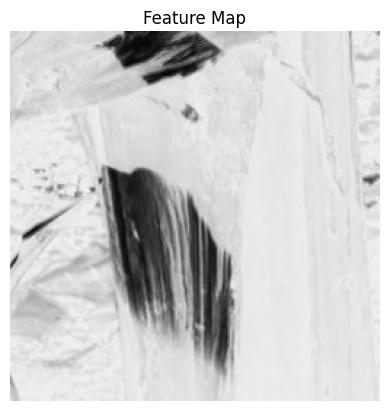

In [19]:
plt.imshow(y[0, 0].detach().cpu(), cmap="gray")
plt.axis("off")
plt.title("Feature Map")
plt.show()

In [20]:
y[0, 0].shape

torch.Size([254, 254])

In [21]:
conv8 = nn.Conv2d(
    in_channels=3,
    out_channels=8,
    kernel_size=3
)

In [22]:
y8 = conv8(x)

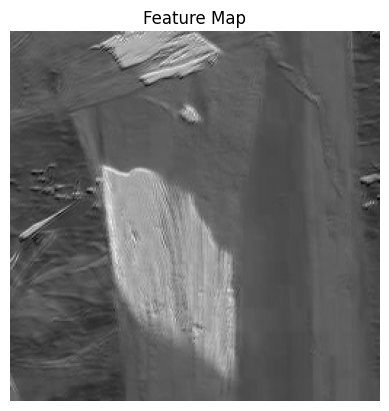

In [23]:
plt.imshow(y8[0, 0].detach().cpu(), cmap="gray")
plt.axis("off")
plt.title("Feature Map")
plt.show()

In [24]:
relu = nn.ReLU()

In [25]:
y_relu = relu(y8)

In [26]:
print(f"Before ReLU - Min: {y8.min()}")
print(f"After ReLU - Min: {y_relu.min()}")

Before ReLU - Min: -164.85464477539062
After ReLU - Min: 0.0


In [27]:
pool = nn.MaxPool2d(kernel_size=2, stride=2)

In [28]:
y_pool = pool(y_relu)

In [29]:
print(f"Before Pooling: {y_relu.shape}")
print(f"After Pooling: {y_pool.shape}")

Before Pooling: torch.Size([1, 8, 254, 254])
After Pooling: torch.Size([1, 8, 127, 127])


In [30]:
conv2 = nn.Conv2d(
    in_channels=8,
    out_channels=16,
    kernel_size=3
)

In [31]:
y2 = conv2(y_pool)

In [32]:
print(f"Shape: {y2.shape}")

Shape: torch.Size([1, 16, 125, 125])


In [33]:
relu2 = nn.ReLU()

In [34]:
y2_relu = relu2(y2)

In [35]:
pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

In [36]:
y2_pool = pool2(y2_relu)

In [37]:
print(f"After ReLU: {y2_relu.shape}")
print(f"After Pool: {y2_pool.shape}")

After ReLU: torch.Size([1, 16, 125, 125])
After Pool: torch.Size([1, 16, 62, 62])


#### Conv layer

In [38]:
conv3 = nn.Conv2d(
    in_channels=16, 
    out_channels=32,
    kernel_size=3
)

y3 = conv3(y2_pool)

### ReLU Layer

In [39]:
relu3 = nn.ReLU()

y3_relu = relu3(y3)

### Max Pool Layer

In [40]:
pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

y3_pool = pool3(y3_relu)

In [41]:
print(f"After ReLU: {y3_relu.shape}")
print(f"After Max Pooling: {y3_pool.shape}")

After ReLU: torch.Size([1, 32, 60, 60])
After Max Pooling: torch.Size([1, 32, 30, 30])


### Flattening

In [42]:
flatten = torch.flatten(y3_pool, start_dim=1)

In [43]:
print(f"Before flattening: {y3_pool.shape}")
print(f"After flattening: {flatten.shape}")

Before flattening: torch.Size([1, 32, 30, 30])
After flattening: torch.Size([1, 28800])


### FC Layer

In [44]:
fc1 = nn.Linear(
    in_features=28800,
    out_features=128
)

fc1_output = fc1(flatten)

print(f"Output Shape: {fc1_output.shape}")

Output Shape: torch.Size([1, 128])


### ReLU 

In [45]:
relu_fc = nn.ReLU()

fc1_relu = relu_fc(fc1_output)

In [46]:
print(f"Shape: {fc1_relu.shape}")

Shape: torch.Size([1, 128])


#### Output

In [47]:
output_layer = nn.Linear(
    in_features=128,
    out_features=5
)

output = output_layer(fc1_relu)

In [51]:
print(f"Output Shape: {output.shape}")
print(f"Output: {output}")

Output Shape: torch.Size([1, 5])
Output: tensor([[-1.3273, -1.4264, -2.3532,  2.7688, -0.7472]],
       grad_fn=<AddmmBackward0>)


In [52]:
probabilities = torch.softmax(output, dim=1)

In [53]:
print(f"Probabilities: {probabilities}")
print(f"Sum: {probabilities.sum()}")

Probabilities: tensor([[0.0156, 0.0141, 0.0056, 0.9369, 0.0278]], grad_fn=<SoftmaxBackward0>)
Sum: 1.0


In [58]:
predicted_class = torch.argmax(probabilities, dim=1)

In [62]:
print(f"Predicted class: {predicted_class.item()}")

Predicted class: 3
